# 02 — Exploratory Data Analysis (EDA)
**Project:** Audible Audiobook Analytics  
**Team:** Team Mars  
**Author:** Nirwan Maharjan  
**Week:** 3  

This notebook performs EDA on the cleaned Audible dataset.  
Input: `../data/audible_cleaned.csv`  
Outputs: plots saved to `../outputs/plots/`

### Sections
1. Setup & Load
2. Descriptive Statistics
3. Distributions (Histograms)
4. Categorical Breakdowns (Bar Charts)
5. Relationships (Scatter & Box Plots)
6. Correlation Heatmap
7. Outlier Detection
8. EDA Summary

---
## 1. Setup & Load

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Create output directory if it doesn't exist
os.makedirs('../outputs/plots', exist_ok=True)

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (11, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

df = pd.read_csv('../data/audible_cleaned.csv', parse_dates=['releasedate'])

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (87419, 10)


,name,author,narrator,language,duration_minutes,releasedate,release_year,star_score,num_ratings,price
0,"Surely You're Joking, Mr. Feynman!",Richard P.Feynman,Raymond Todd,English,691,1998-12-27,1998,4.5,328.0,773.0
1,"Men Are from Mars, Women Are from Venus",John Gray,John Gray,English,568,1998-12-27,1998,4.5,166.0,1519.0
2,Letters to a Young Poet,"Rainer Maria Rilke,Stephen Mitchell-translator",Stephen Mitchell,English,78,1998-12-27,1998,5.0,2.0,233.0
3,"Rhetoric, Poetics and Logic",Aristotle,Frederick Davidson,English,808,1999-05-10,1999,0.0,0.0,773.0
4,Wealth of Nations,Adam Smith,Michael Edwards,English,2119,1999-05-10,1999,0.0,0.0,1338.0


---
## 2. Descriptive Statistics

Summary statistics for all numeric columns. This table will be included directly in the final report.

In [13]:
numeric_cols = ['price', 'star_score', 'num_ratings', 'duration_minutes', 'release_year']

stats = df[numeric_cols].describe().T
stats['median'] = df[numeric_cols].median()
stats['IQR']    = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
stats = stats[['count', 'mean', 'median', 'std', 'min', '25%', '75%', 'max', 'IQR']]
stats.round(2)

,count,mean,median,std,min,25%,75%,max,IQR
price,87419.0,558.99,585.0,336.06,0.0,268.0,755.0,7198.0,487.0
star_score,87419.0,0.77,0.0,1.71,0.0,0.0,0.0,5.0,0.0
num_ratings,87419.0,3.37,0.0,71.69,0.0,0.0,0.0,12573.0,0.0
duration_minutes,87419.0,417.55,386.0,364.62,1.0,142.0,584.0,8595.0,442.0
release_year,87419.0,2017.99,2020.0,4.26,1998.0,2016.0,2021.0,2025.0,5.0


---
## 3. Distributions — Histograms

Understanding the shape of each numeric variable before modeling.

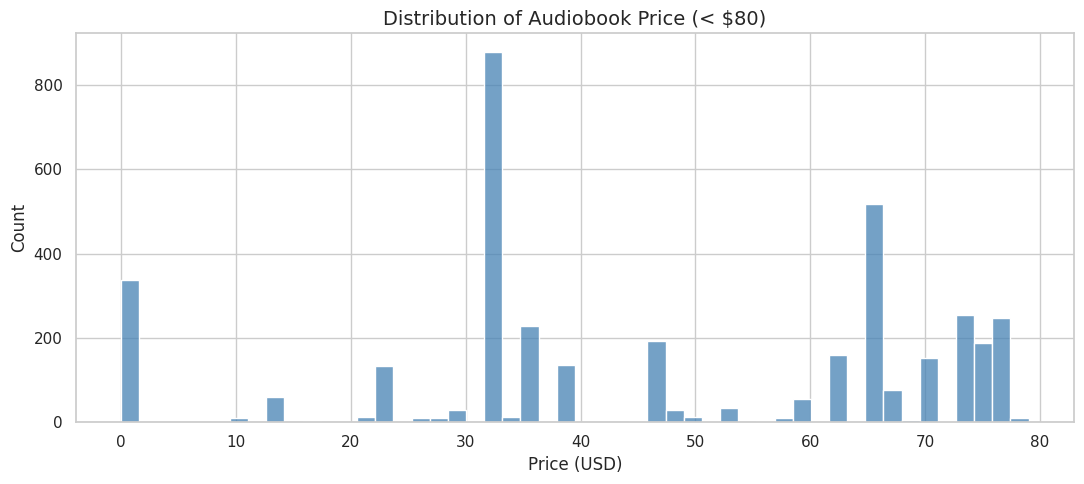

In [14]:
# --- Price Distribution ---
fig, ax = plt.subplots()
price_filtered = df[df['price'] < 80]['price']
sns.histplot(price_filtered, bins=50, color='steelblue', ax=ax)
ax.set_title('Distribution of Audiobook Price (< $80)')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/plots/hist_price.png', dpi=150)
plt.show()

**Insight:** *(Write 1–2 sentences here about what the price distribution shows — e.g. where most audiobooks are priced, whether the distribution is skewed, etc.)*

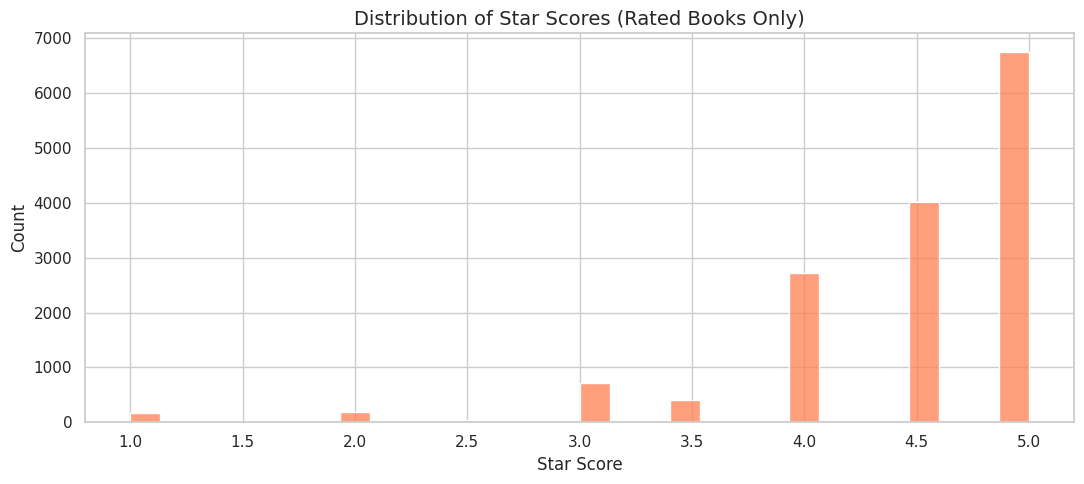

In [15]:
# --- Star Score Distribution ---
fig, ax = plt.subplots()
rated = df[df['star_score'] > 0]['star_score']
sns.histplot(rated, bins=30, color='coral', ax=ax)
ax.set_title('Distribution of Star Scores (Rated Books Only)')
ax.set_xlabel('Star Score')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/plots/hist_star_score.png', dpi=150)
plt.show()

**Insight:** *(Describe the shape — is it left-skewed? Are most books rated 4+? Note what this means for our logistic regression cutoff of 4.0.)*

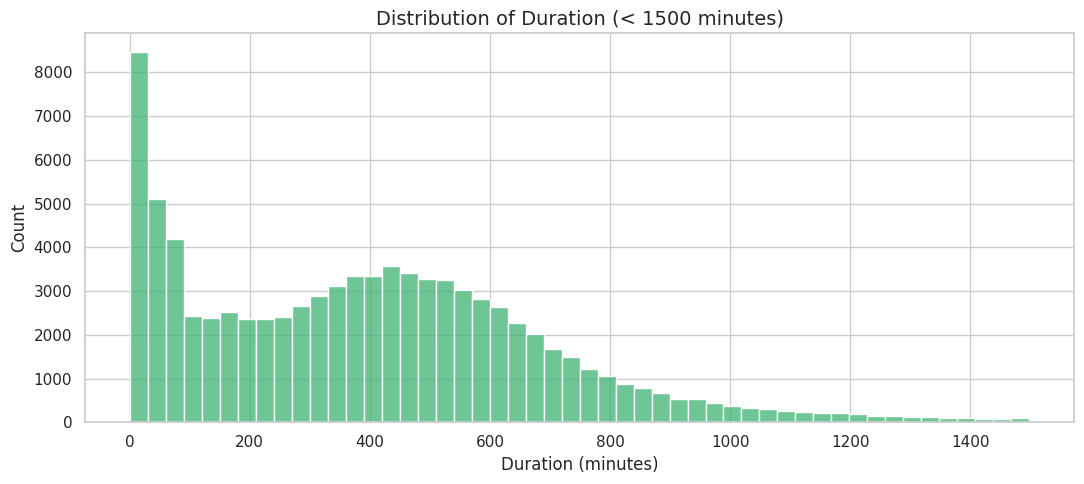

In [16]:
# --- Duration Distribution ---
fig, ax = plt.subplots()
dur_filtered = df[df['duration_minutes'] < 1500]['duration_minutes']
sns.histplot(dur_filtered, bins=50, color='mediumseagreen', ax=ax)
ax.set_title('Distribution of Duration (< 1500 minutes)')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/plots/hist_duration.png', dpi=150)
plt.show()

**Insight:** *(What is a typical audiobook length? Is the distribution right-skewed? Are there very long outliers?)*

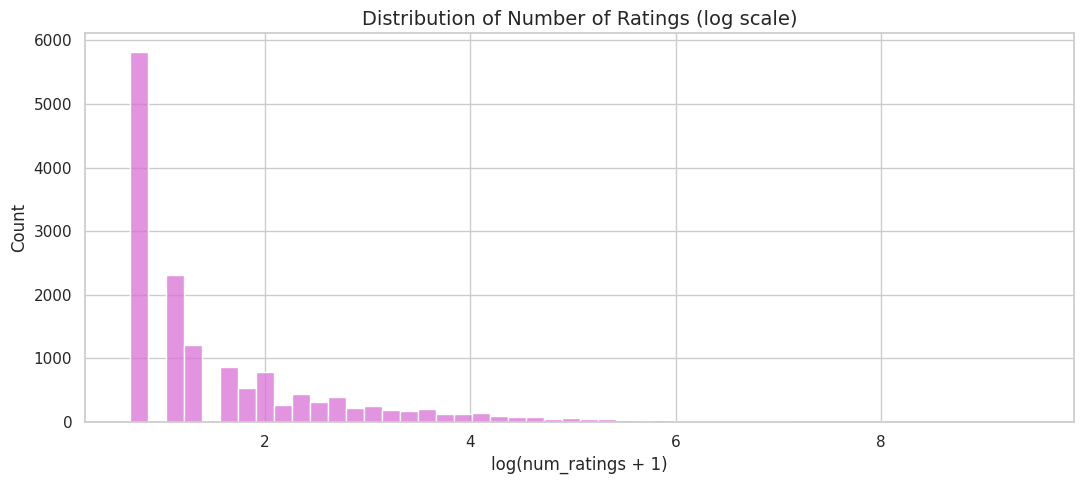

In [17]:
# --- Number of Ratings Distribution (log scale) ---
fig, ax = plt.subplots()
rated_count = df[df['num_ratings'] > 0]['num_ratings']
sns.histplot(np.log1p(rated_count), bins=50, color='orchid', ax=ax)
ax.set_title('Distribution of Number of Ratings (log scale)')
ax.set_xlabel('log(num_ratings + 1)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/plots/hist_num_ratings.png', dpi=150)
plt.show()

**Insight:** *(Note the extreme skew without log transformation. This justifies using log(num_ratings + 1) as a feature in the models.)*

---
## 4. Categorical Breakdowns

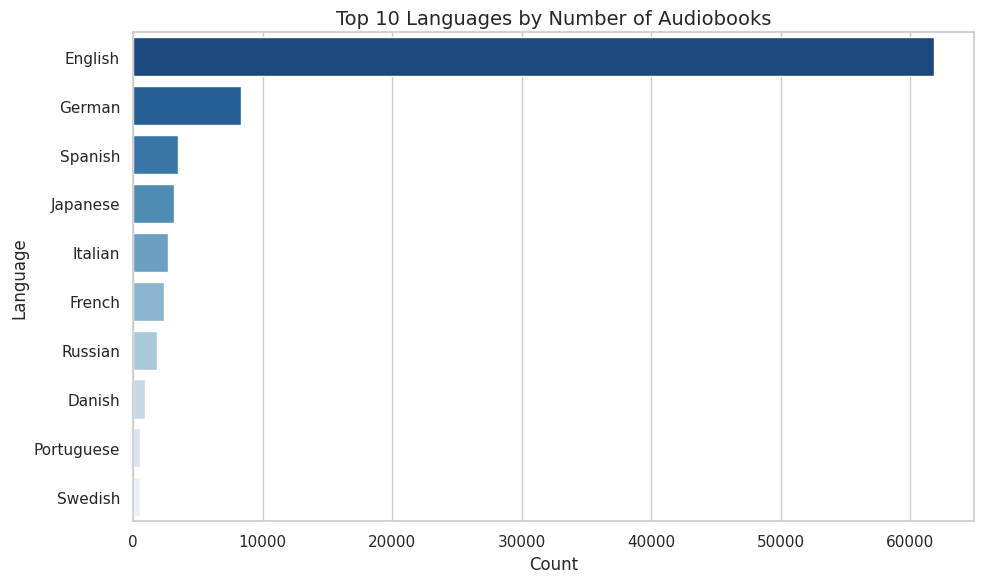

In [18]:
# --- Top 10 Languages ---
top_langs = df['language'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_langs.values, y=top_langs.index, palette='Blues_r', ax=ax)
ax.set_title('Top 10 Languages by Number of Audiobooks')
ax.set_xlabel('Count')
ax.set_ylabel('Language')
plt.tight_layout()
plt.savefig('../outputs/plots/bar_languages.png', dpi=150)
plt.show()

**Insight:** *(Which language dominates? What does this mean for language as a feature — should we group rare languages into an 'Other' category?)*

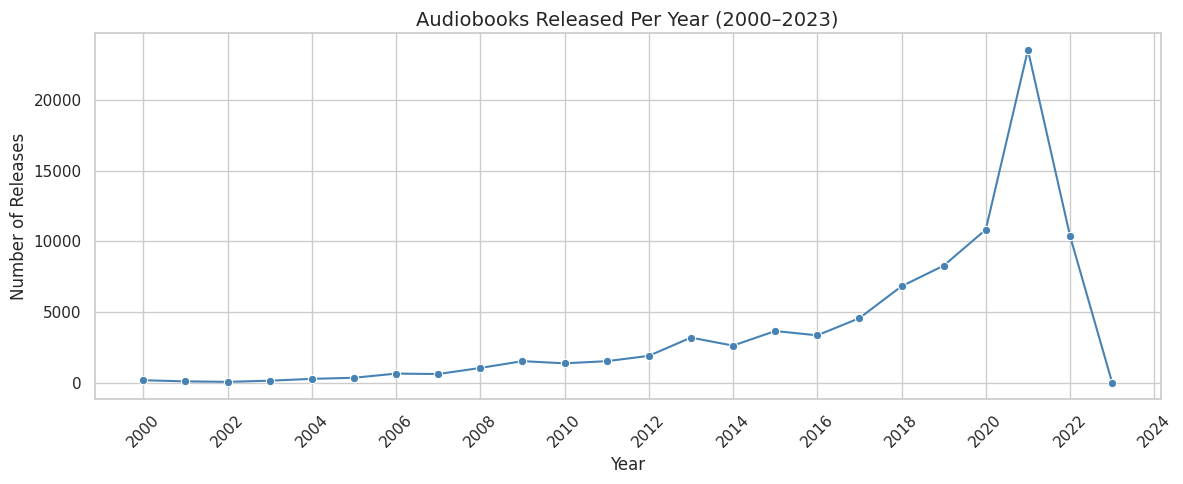

In [19]:
# --- Audiobooks Released Per Year ---
year_counts = (
    df['release_year']
    .value_counts()
    .sort_index()
)
year_counts = year_counts[(year_counts.index >= 2000) & (year_counts.index <= 2023)]

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='steelblue', ax=ax)
ax.set_title('Audiobooks Released Per Year (2000–2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Releases')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/plots/line_releases_per_year.png', dpi=150)
plt.show()

**Insight:** *(Is the audiobook market growing? When did the biggest spike in releases happen? Does this affect how release_year should be treated as a feature?)*

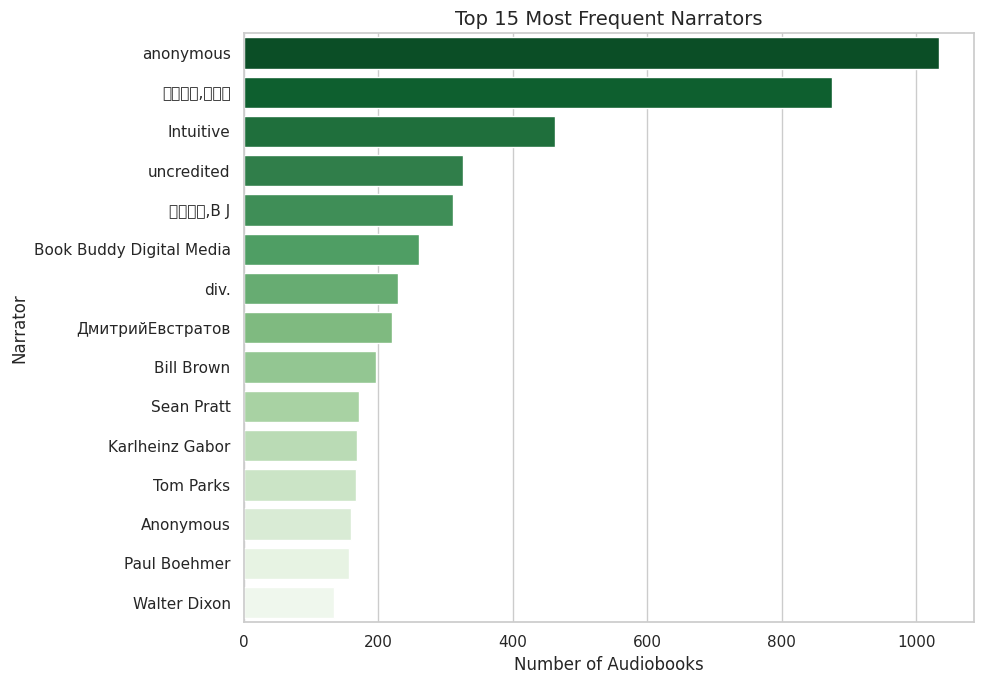

In [20]:
# --- Top 15 Most Frequent Narrators ---
top_narrators = df['narrator'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_narrators.values, y=top_narrators.index, palette='Greens_r', ax=ax)
ax.set_title('Top 15 Most Frequent Narrators')
ax.set_xlabel('Number of Audiobooks')
ax.set_ylabel('Narrator')
plt.tight_layout()
plt.savefig('../outputs/plots/bar_top_narrators.png', dpi=150)
plt.show()

**Insight:** *(How many books does the top narrator have? This justifies creating the `is_top_narrator` engineered feature — some narrators are significantly more prolific.)*

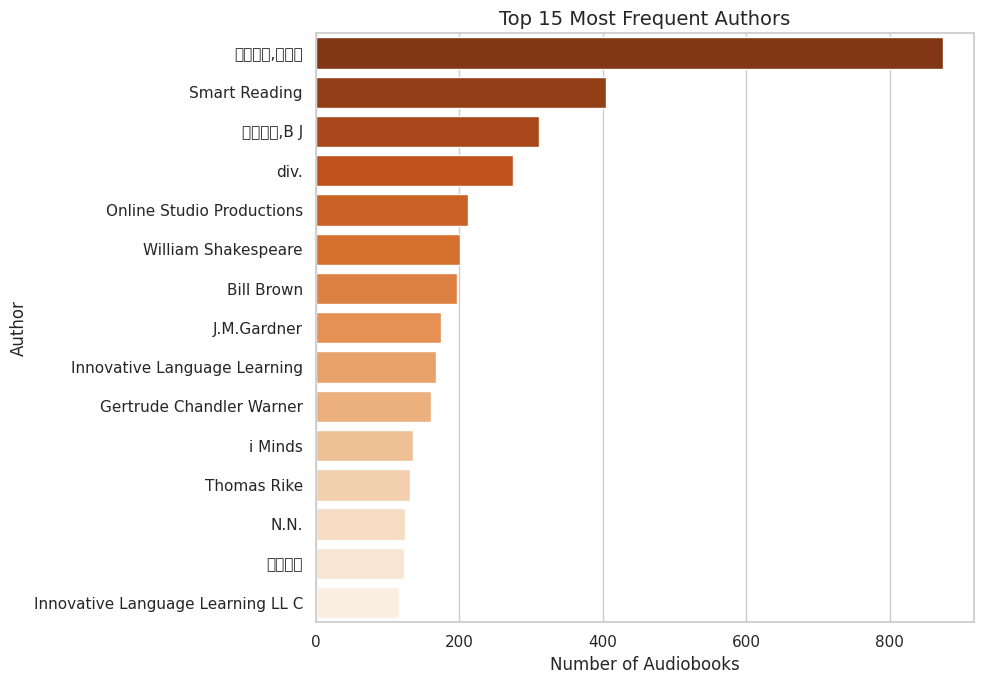

In [21]:
# --- Top 15 Most Frequent Authors ---
top_authors = df['author'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='Oranges_r', ax=ax)
ax.set_title('Top 15 Most Frequent Authors')
ax.set_xlabel('Number of Audiobooks')
ax.set_ylabel('Author')
plt.tight_layout()
plt.savefig('../outputs/plots/bar_top_authors.png', dpi=150)
plt.show()

**Insight:** *(Note the most prolific authors. Same logic as narrator — a few authors dominate the catalog.)*

---
## 5. Relationships — Scatter & Box Plots

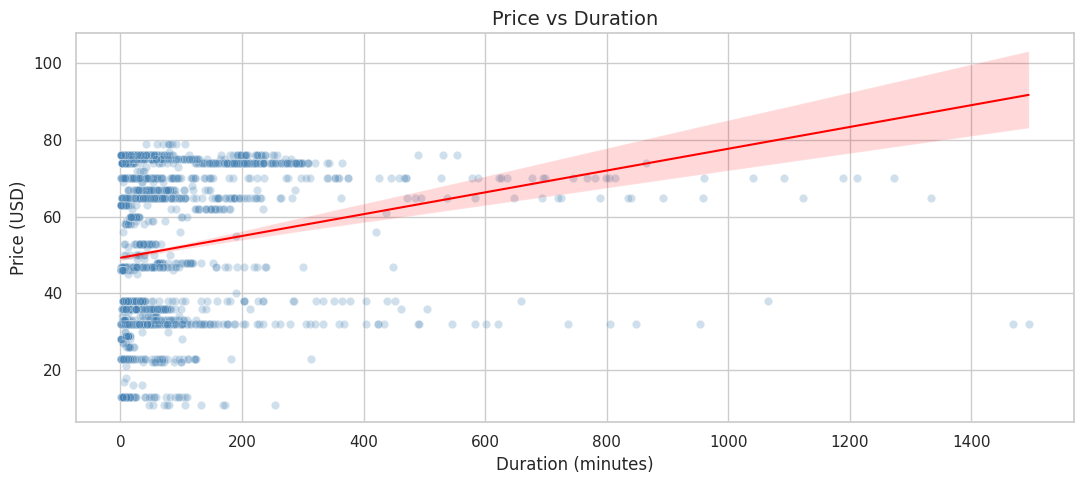

In [22]:
# --- Price vs Duration ---
filtered = df[(df['price'] > 0) & (df['price'] < 80) & (df['duration_minutes'] < 1500)]
sample = filtered.sample(min(4000, len(filtered)), random_state=42)  # len(filtered), not len(df)

fig, ax = plt.subplots()
sns.scatterplot(data=sample, x='duration_minutes', y='price', alpha=0.25, color='steelblue', ax=ax)
sns.regplot(data=sample, x='duration_minutes', y='price',
            scatter=False, color='red', line_kws={'linewidth': 1.5}, ax=ax)
ax.set_title('Price vs Duration')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('../outputs/plots/scatter_price_vs_duration.png', dpi=150)
plt.show()

**Insight:** *(Is there a positive trend? How strong does it look visually? The red regression line helps show direction even before running the model.)*

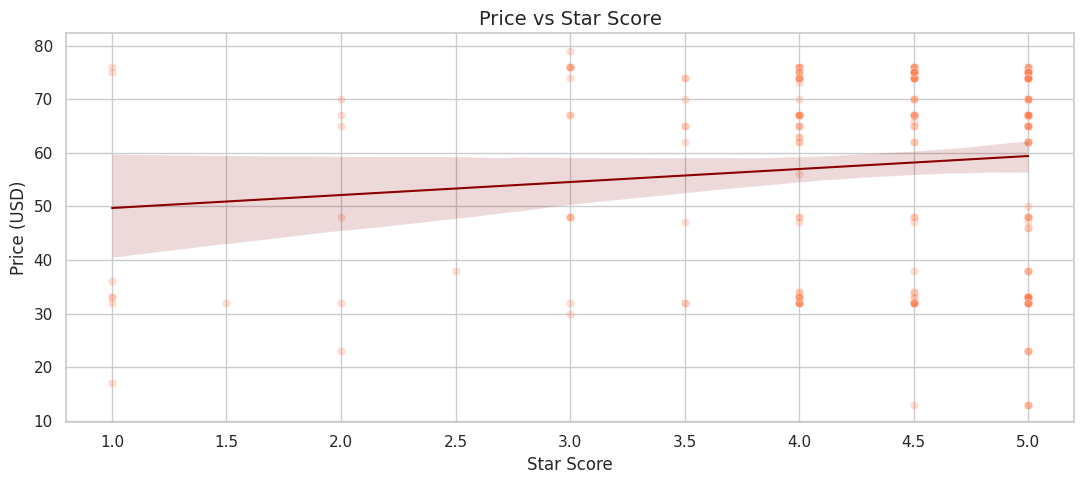

In [23]:
# --- Price vs Star Score ---
filtered2 = df[(df['price'] > 0) & (df['price'] < 80) & (df['star_score'] > 0)]
sample2 = filtered2.sample(min(4000, len(filtered2)), random_state=42)

fig, ax = plt.subplots()
sns.scatterplot(data=sample2, x='star_score', y='price', alpha=0.25, color='coral', ax=ax)
sns.regplot(data=sample2, x='star_score', y='price',
            scatter=False, color='darkred', line_kws={'linewidth': 1.5}, ax=ax)
ax.set_title('Price vs Star Score')
ax.set_xlabel('Star Score')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('../outputs/plots/scatter_price_vs_stars.png', dpi=150)
plt.show()

**Insight:** *(Is there a clear relationship between rating and price? A weak or flat line here would suggest star score alone isn't a strong price predictor.)*

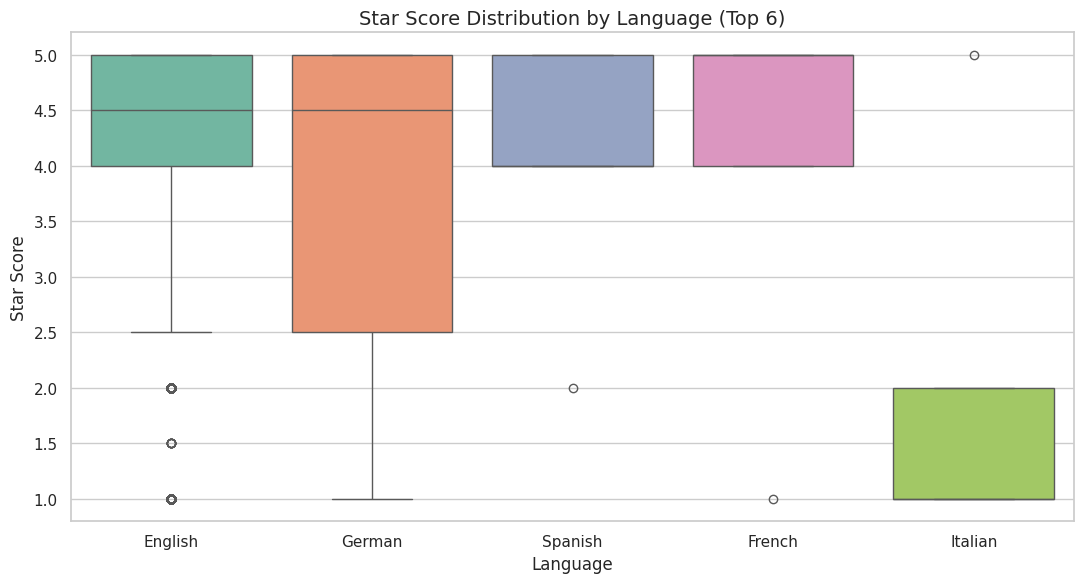

In [24]:
# --- Star Score by Language (Box Plot) ---
top_lang_list = df['language'].value_counts().head(6).index.tolist()
lang_df = df[(df['language'].isin(top_lang_list)) & (df['star_score'] > 0)]

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=lang_df, x='language', y='star_score', palette='Set2', ax=ax)
ax.set_title('Star Score Distribution by Language (Top 6)')
ax.set_xlabel('Language')
ax.set_ylabel('Star Score')
plt.tight_layout()
plt.savefig('../outputs/plots/box_stars_by_language.png', dpi=150)
plt.show()

**Insight:** *(Do different languages have different median ratings? Any notable differences in spread? This motivates including language in the logistic regression model.)*

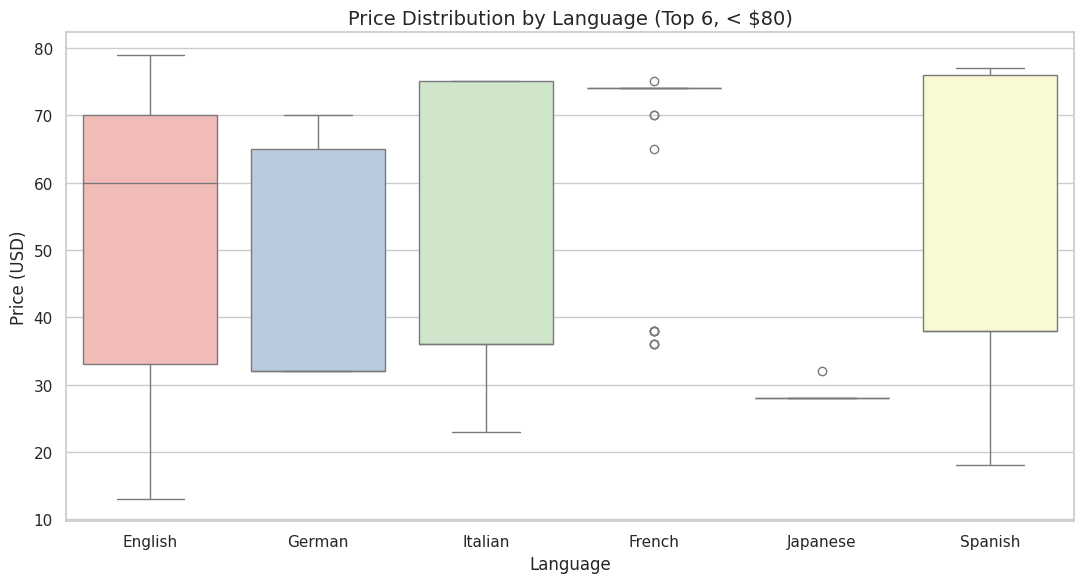

In [25]:
# --- Price by Language (Box Plot) ---
price_lang_df = df[(df['language'].isin(top_lang_list)) & (df['price'] > 0) & (df['price'] < 80)]

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=price_lang_df, x='language', y='price', palette='Pastel1', ax=ax)
ax.set_title('Price Distribution by Language (Top 6, < $80)')
ax.set_xlabel('Language')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('../outputs/plots/box_price_by_language.png', dpi=150)
plt.show()

**Insight:** *(Do audiobooks in certain languages cost more? This supports using language as a feature in the linear regression price model.)*

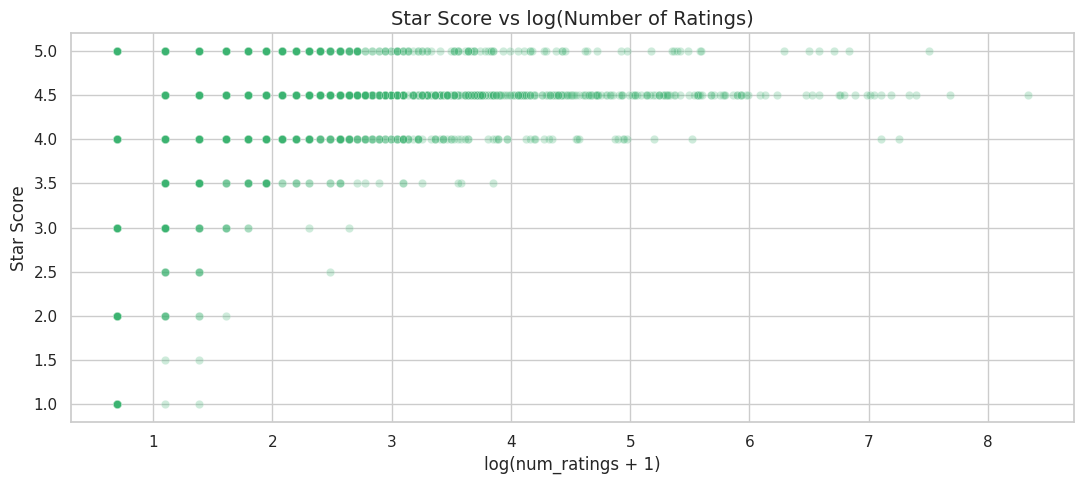

In [26]:
# --- Number of Ratings vs Star Score ---
filtered3 = df[(df['star_score'] > 0) & (df['num_ratings'] > 0)]
sample3 = filtered3.sample(min(4000, len(filtered3)), random_state=42)

fig, ax = plt.subplots()
sns.scatterplot(data=sample3, x=np.log1p(sample3['num_ratings']),
                y='star_score', alpha=0.25, color='mediumseagreen', ax=ax)
ax.set_title('Star Score vs log(Number of Ratings)')
ax.set_xlabel('log(num_ratings + 1)')
ax.set_ylabel('Star Score')
plt.tight_layout()
plt.savefig('../outputs/plots/scatter_ratings_vs_stars.png', dpi=150)
plt.show()

**Insight:** *(Do books with more reviews tend to have higher or more stable ratings? Or is the relationship weak? This tests whether popularity correlates with quality.)*

---
## 6. Correlation Heatmap

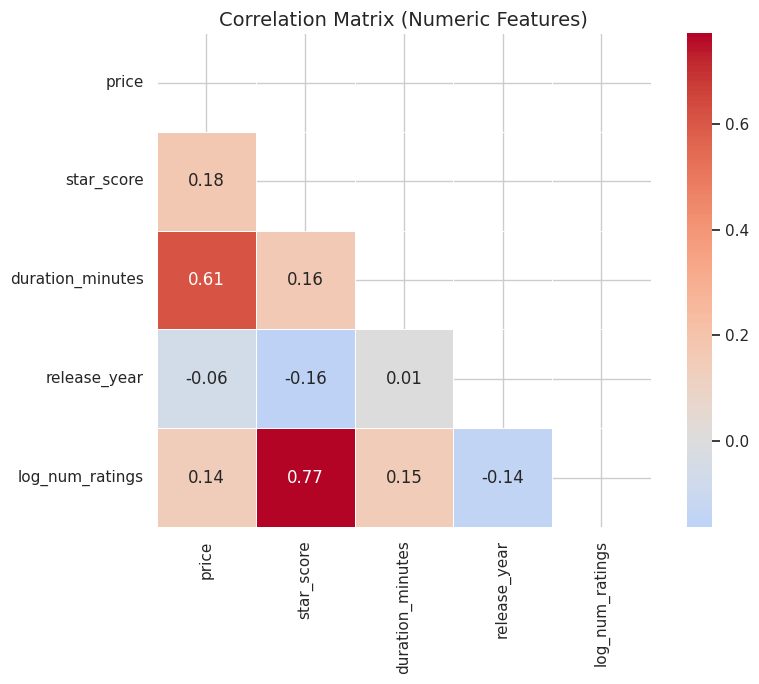

In [27]:
corr_df = df[numeric_cols].copy()
corr_df['log_num_ratings'] = np.log1p(corr_df['num_ratings'])
corr_df.drop(columns=['num_ratings'], inplace=True)

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.savefig('../outputs/plots/heatmap_correlation.png', dpi=150)
plt.show()

**Insight:** *(Which pairs of features are most correlated? Are any features highly correlated with each other (multicollinearity risk for regression)? Which features correlate most with price?)*

---
## 7. Outlier Detection

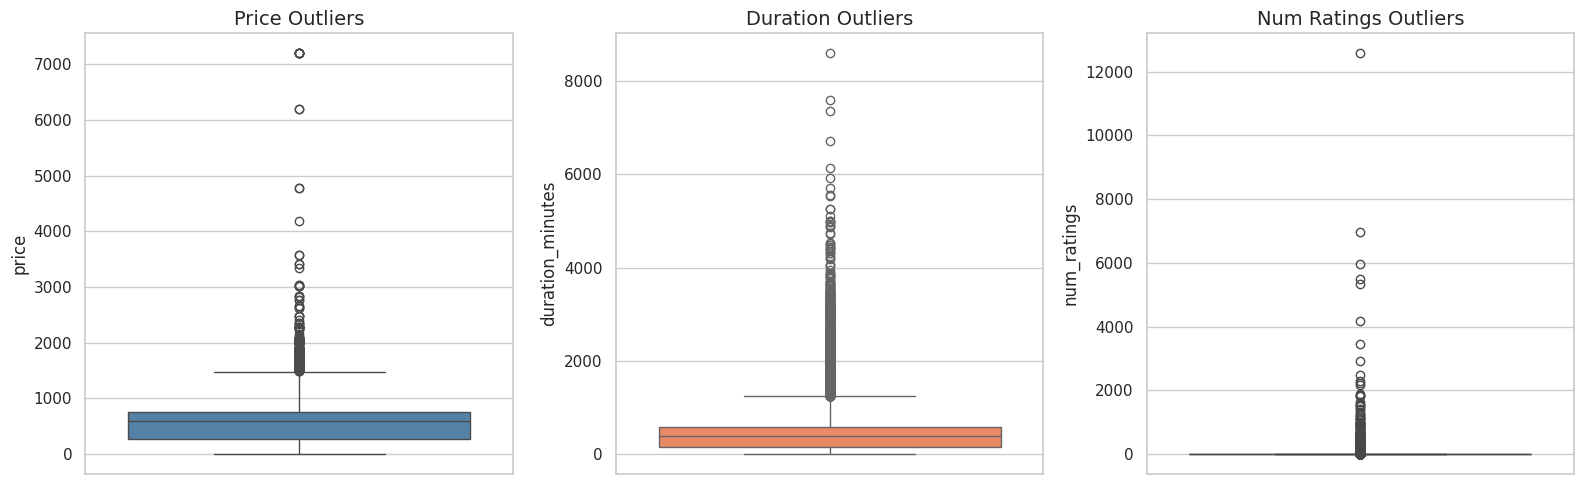

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=df['price'],            ax=axes[0], color='steelblue')
axes[0].set_title('Price Outliers')

sns.boxplot(y=df['duration_minutes'], ax=axes[1], color='coral')
axes[1].set_title('Duration Outliers')

sns.boxplot(y=df['num_ratings'],      ax=axes[2], color='mediumseagreen')
axes[2].set_title('Num Ratings Outliers')

plt.tight_layout()
plt.savefig('../outputs/plots/boxplot_outliers.png', dpi=150)
plt.show()

In [29]:
# Count outliers using IQR method
print('=== Outlier Report (IQR method) ===')
for col in ['price', 'duration_minutes', 'num_ratings']:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / len(df) * 100
    print(f'{col:20s} | lower: {lower:8.2f} | upper: {upper:8.2f} | outliers: {n_out} ({pct:.1f}%)')

=== Outlier Report (IQR method) ===
price                | lower:  -462.50 | upper:  1485.50 | outliers: 703 (0.8%)
duration_minutes     | lower:  -521.00 | upper:  1247.00 | outliers: 2097 (2.4%)
num_ratings          | lower:     0.00 | upper:     0.00 | outliers: 15029 (17.2%)


**Decision on outliers:**  
*(Write your decision here — e.g. 'We will cap price at the 99th percentile rather than removing rows, to preserve sample size while reducing the influence of extreme values on regression.')*

In [30]:
# Cap outliers at 99th percentile for price and duration (rather than dropping rows)
for col in ['price', 'duration_minutes']:
    cap = df[col].quantile(0.99)
    before = len(df[df[col] > cap])
    df[col] = df[col].clip(upper=cap)
    print(f'{col}: capped {before} values at {cap:.2f}')

price: capped 785 values at 1407.00
duration_minutes: capped 875 values at 1656.82


---
## 8. EDA Summary

Fill this in after reviewing all plots. This section goes directly into the Week 3 report.

### Key Findings

**Price:**
- *(e.g. Most audiobooks are priced between $X and $Y. The distribution is right-skewed with a long tail of premium titles.)*

**Star Score:**
- *(e.g. The majority of rated books score between 4.0 and 5.0, confirming a left-skewed distribution. This supports our binary cutoff of 4.0 for logistic regression.)*

**Duration:**
- *(e.g. Most audiobooks are between X and Y minutes. Extreme outliers (> Z minutes) were capped at the 99th percentile.)*

**Language:**
- *(e.g. English dominates the catalog at ~X%. German, Spanish, and French are the next most common. Rare languages will be grouped as 'Other' for modeling.)*

**Narrator & Author:**
- *(e.g. The top narrator appears in X books — far more than the average. This justifies the `is_top_narrator` binary feature.)*

**Correlations:**
- *(e.g. Duration shows the strongest positive correlation with price (r = X). Star score and price are weakly correlated (r = X), suggesting price is driven more by content length than quality.)*

### Features Confirmed for Modeling
| Feature | Type | Use in Models |
|---------|------|---------------|
| `duration_minutes` | Numeric | Linear + Logistic |
| `price` | Numeric | Logistic (predictor) / Linear (target) |
| `star_score` | Numeric | Linear (predictor) / Logistic (source of target) |
| `log_num_ratings` | Numeric (engineered) | Linear + Logistic |
| `release_year` | Numeric | Linear + Logistic |
| `language` (encoded) | Categorical | Linear + Logistic |
| `is_top_narrator` | Binary (engineered) | Linear + Logistic |
| `is_top_author` | Binary (engineered) | Linear + Logistic |

In [31]:
# Save final version of cleaned + capped df for use in modeling notebooks
df.to_csv('../data/audible_cleaned.csv', index=False)
print('Updated audible_cleaned.csv saved.')
print(f'Final shape: {df.shape}')

Updated audible_cleaned.csv saved.
Final shape: (87419, 10)
